<a href="https://colab.research.google.com/github/Shaimaod/natcat-analysis/blob/main/natcat-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Catastrophes Analysis — Global Data 2000-2025

## Context
Natural catastrophes represent a major challenge for the insurance and
reinsurance industry. Every year, billions of dollars in economic losses
are recorded worldwide, but a large share of these losses are not
covered by any insurance policy.

This gap between total economic losses and insured losses is called
the **protection gap**. It is one of the central issues for reinsurers
such as Swiss Re, Munich Re or AXA XL.

## Objective
The goal of this project is to analyze public EM-DAT data to:
- Visualize the evolution of natural catastrophes over 25 years
- Identify the most frequent and most costly types of events
- Quantify the protection gap at a global scale
- Identify the countries most economically exposed

**Data source:** EM-DAT, CRED — Université catholique de Louvain (emdat.be)  
**Period:** 2000–2025  
**Tools:** Python, Pandas, Matplotlib, Seaborn

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chargement des données
df = pd.read_excel('/public_emdat_custom_request_2026-06-15_aef81891-47b3-460c-ba97-b6042bbefca5.xlsx')

# Aperçu
print(df.shape)
df.head()

(10764, 47)


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2025-0303-ECU,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,ECU,...,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,2025-04-28,2026-05-15
1,2026-0153-KEN,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,KEN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-09,2026-05-15
2,2025-0750-AFG,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,GLIDE:EQ-2025-000153,NaN,AFG,...,NaN,NaN,NaN,180000.0,180000.0,100.0,NaN,NaN,2025-09-01,2026-05-15
3,2026-0305-AFG,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,AFG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-04,2026-05-11
4,2024-0962-AGO,No,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,GLIDE:EP-2025-000013,Cholera,AGO,...,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,2025-01-17,2026-05-15


## 1. Evolution of the Number of Natural Catastrophes

We start with an overview: how many natural catastrophes are recorded
each year worldwide?

The goal is to assess whether the frequency of events is increasing,
decreasing, or remaining stable over the 2000–2025 period.

Note: the drop observed in 2026 is due to the fact that the year
was not yet complete at the time of data extraction.

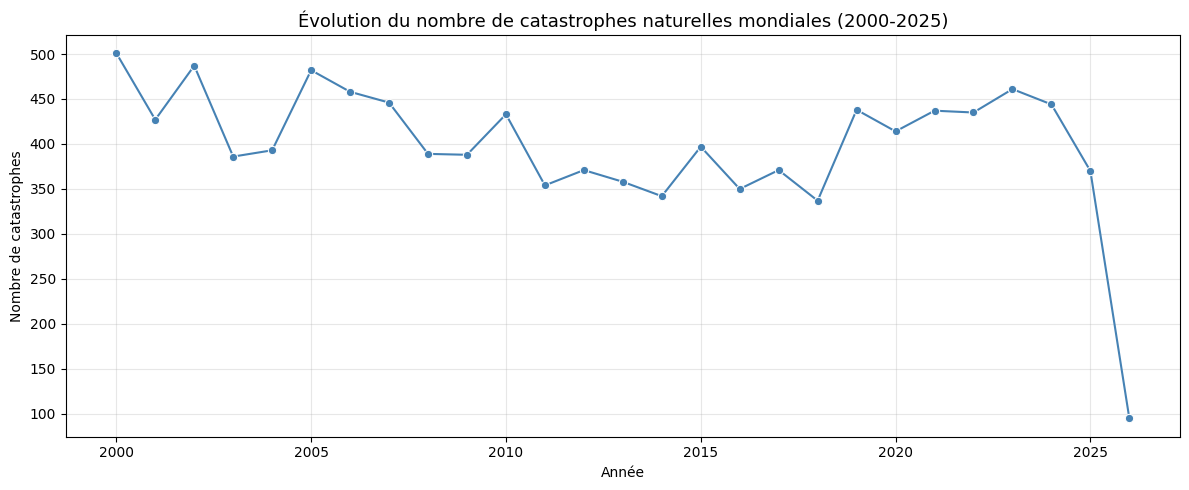

In [13]:
# Nettoyage de base
df_clean = df[df['Disaster Group'] == 'Natural'].copy()
df_clean = df_clean[df_clean['Start Year'] >= 2000]

# Evolution du nombre de catastrophes par an
catastrophes_par_an = df_clean.groupby('Start Year').size().reset_index(name='Nombre')

plt.figure(figsize=(12, 5))
sns.lineplot(data=catastrophes_par_an, x='Start Year', y='Nombre', marker='o', color='steelblue')
plt.title('Évolution du nombre de catastrophes naturelles mondiales (2000-2025)', fontsize=13)
plt.xlabel('Année')
plt.ylabel('Nombre de catastrophes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('01_evolution_catastrophes.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Observation
The number of catastrophes remains relatively stable, fluctuating
between 350 and 500 events per year, with no clear upward trend.

This may seem counterintuitive given the discourse around climate change, but what is actually evolving is the **severity** of events,
not necessarily their frequency.

## 2. Most Frequent Types of Natural Catastrophes

We now analyze the distribution by disaster type to identify
which risks dominate in terms of frequency.

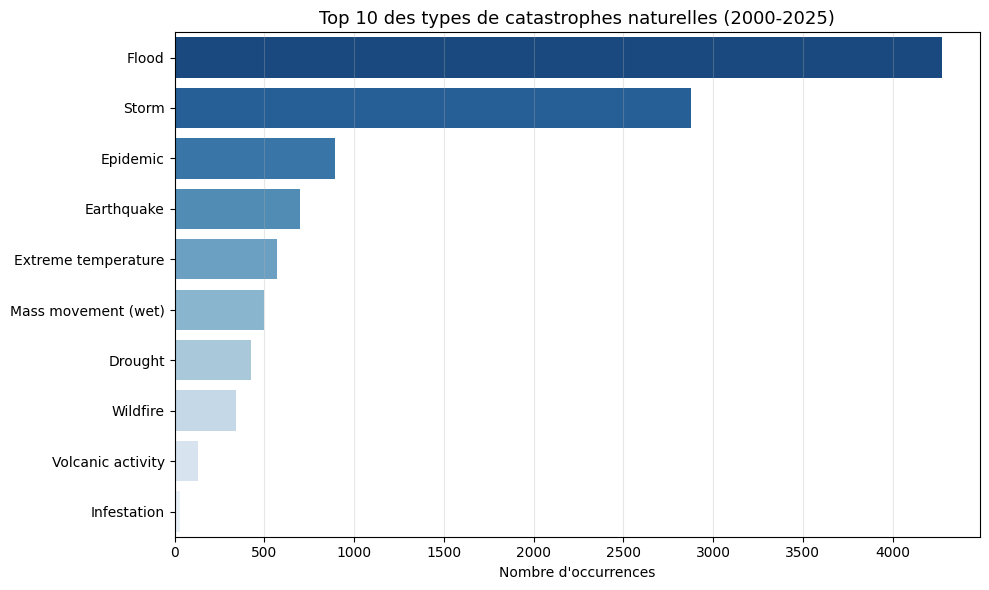

In [14]:
# Top types de catastrophes
top_types = df_clean['Disaster Type'].value_counts().head(10).reset_index()
top_types.columns = ['Type', 'Nombre']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_types, x='Nombre', y='Type', palette='Blues_r')
plt.title('Top 10 des types de catastrophes naturelles (2000-2025)', fontsize=13)
plt.xlabel('Nombre d\'occurrences')
plt.ylabel('')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('02_top_types_catastrophes.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Observation
Floods and storms dominate by a large margin, together accounting
for the majority of recorded events.

These are precisely the risks most commonly covered by NatCat
(natural catastrophe) reinsurance treaties.

## 3. The Protection Gap: Economic Losses vs Insured Losses

This is the core visualization of this project.

The **protection gap** refers to the difference between:
- **Total economic losses**: the full extent of damage caused by a catastrophe
- **Insured losses**: the share actually covered by insurance contracts

In developed countries, this gap is already significant.
In developing countries, it can reach 90% , meaning that 90% of losses
are borne directly by victims or governments.

Closing this gap is one of the key strategic challenges
for the reinsurance industry today.

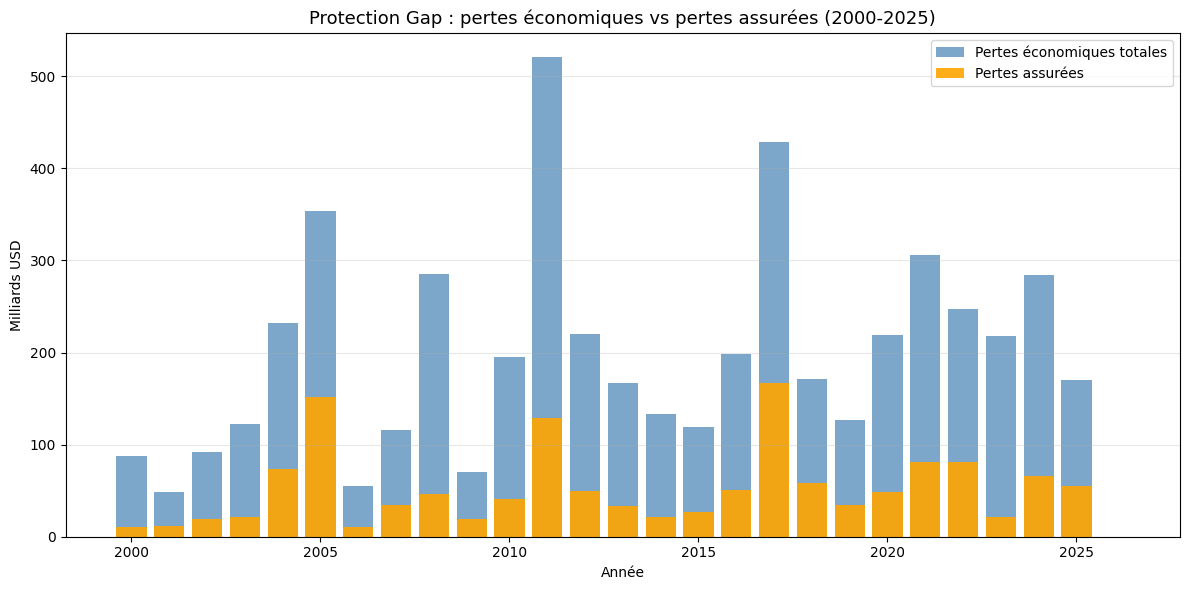

In [15]:
# Protection gap par année
gap = df_clean.groupby('Start Year').agg(
    Total_Damage=("Total Damage, Adjusted ('000 US$)", 'sum'),
    Insured_Damage=("Insured Damage, Adjusted ('000 US$)", 'sum')
).reset_index()

# Conversion en milliards
gap['Total_Damage'] = gap['Total_Damage'] / 1e6
gap['Insured_Damage'] = gap['Insured_Damage'] / 1e6

plt.figure(figsize=(12, 6))
plt.bar(gap['Start Year'], gap['Total_Damage'], label='Pertes économiques totales', color='steelblue', alpha=0.7)
plt.bar(gap['Start Year'], gap['Insured_Damage'], label='Pertes assurées', color='orange', alpha=0.9)
plt.title('Protection Gap : pertes économiques vs pertes assurées (2000-2025)', fontsize=13)
plt.xlabel('Année')
plt.ylabel('Milliards USD')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('03_protection_gap.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Observation
Insured losses (orange) consistently represent a minority share
of total economic losses.

Two peaks stand out:
- **2011**: Japan tsunami + Thailand floods
- **2017**: Exceptional hurricane season (Harvey, Irma, Maria)

These years illustrate how concentrated events can generate
massive losses in a very short period of time, a risk that
reinsurers must model and absorb.

## 4. Most Economically Affected Countries

We identify the 10 countries with the highest cumulative economic losses
over the 2000–2025 period.

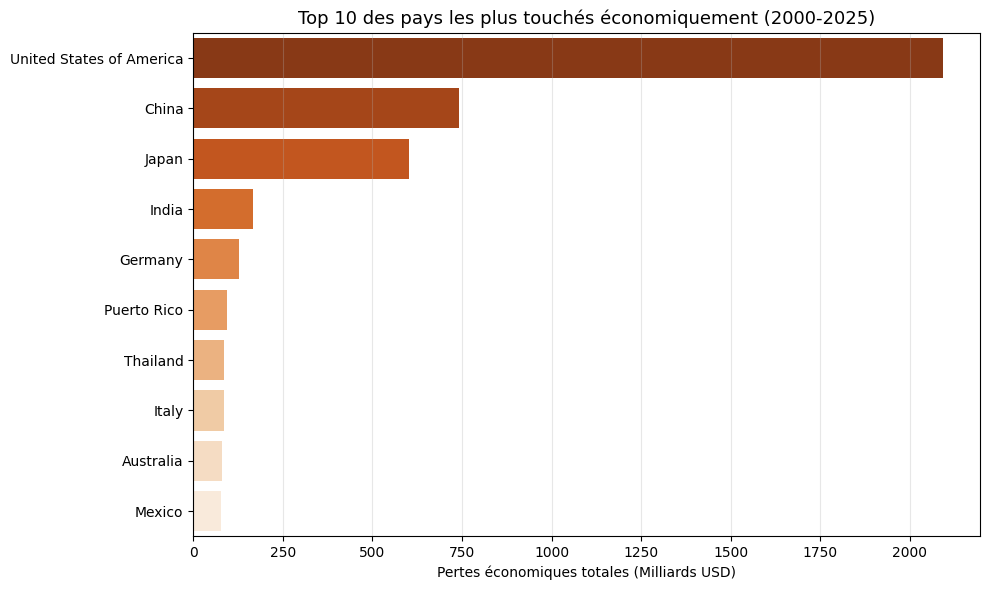

In [16]:
# Top 10 pays les plus touchés
top_pays = df_clean.groupby('Country').agg(
    Total_Damage=("Total Damage, Adjusted ('000 US$)", 'sum')
).reset_index()
top_pays['Total_Damage'] = top_pays['Total_Damage'] / 1e6
top_pays = top_pays.sort_values('Total_Damage', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_pays, x='Total_Damage', y='Country', palette='Oranges_r')
plt.title('Top 10 des pays les plus touchés économiquement (2000-2025)', fontsize=13)
plt.xlabel('Pertes économiques totales (Milliards USD)')
plt.ylabel('')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('04_top_pays.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Observation
The United States dominate with over $2,000 billion in cumulative losses,
nearly three times more than China (2nd).

This is explained by their geographic exposure (hurricanes, tornadoes,
floods, wildfires) and the high value of exposed assets.

Puerto Rico's presence in the top 10 is largely driven by Hurricane Maria
in 2017, which caused devastating losses on a relatively small territory.

## Conclusion

This project highlights three fundamental realities of NatCat risk:

1. **Frequency is stable but severity is increasing** years like 2011
and 2017 show that a single year can concentrate historically
exceptional losses.

2. **The protection gap remains massive** a large majority of global
economic losses are not covered by insurance, representing both
a systemic risk and a development opportunity for the industry.

3. **Exposure is geographically concentrated** the United States,
China and Japan account for the bulk of economic losses,
which shapes the portfolios of major global reinsurers.

---
*Data: EM-DAT, CRED — Université catholique de Louvain*  
*Personal project — June 2026*